In [1]:
import pandas as pd
train_dataset = pd.read_csv(r"D:\File\Preprocessed_data\train_set.csv")
journal_dataset = pd.read_csv(r"D:\File\Preprocessed_data\journal_category.csv")

In [1]:
import torch
# Check if CUDA is available
print(f"Is CUDA supported by this system? {torch.cuda.is_available()}")
# Print CUDA version
print(f"CUDA version: {torch.version.cuda}")
# Get current CUDA device ID
cuda_id = torch.cuda.current_device()
print(f"ID of current CUDA device: {cuda_id}")
# Get name of the current CUDA device
print(f"Name of current CUDA device: {torch.cuda.get_device_name(cuda_id)}")

Is CUDA supported by this system? True
CUDA version: 12.1
ID of current CUDA device: 0
Name of current CUDA device: NVIDIA GeForce RTX 3060 Laptop GPU


# Simple Infos

In [2]:
train_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 842424 entries, 0 to 842423
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   Title     842424 non-null  str  
 1   Abstract  842424 non-null  str  
 2   Keywords  635583 non-null  str  
 3   Label     842424 non-null  int64
dtypes: int64(1), str(3)
memory usage: 1.4 GB


In [6]:
# Basic EDA for train_dataset
print(f"Shape: {train_dataset.shape}")
print(f"Columns: {list(train_dataset.columns)}")

dup_all = train_dataset.duplicated().sum()
print(f"\nDuplicate rows (all columns): {dup_all} ({dup_all / len(train_dataset):.2%})")

lower_to_actual = {c.lower(): c for c in train_dataset.columns}

# Try to detect a text column for duplicate text checks.
text_candidates = ["text", "sentence", "content", "review", "comment", "tweet", "post", "question", "title"]
text_col = next((lower_to_actual[c] for c in text_candidates if c in lower_to_actual), None)

if text_col is None:
    object_cols = train_dataset.select_dtypes(include=["object", "string"]).columns.tolist()
    text_col = object_cols[0] if object_cols else None

if text_col:
    dup_text = train_dataset[text_col].duplicated().sum()
    print(f"Duplicate values in '{text_col}': {dup_text} ({dup_text / len(train_dataset):.2%})")

# Try to detect the label column.
label_candidates = ["label", "labels", "target", "class", "category", "intent", "y"]
label_col = next((lower_to_actual[c] for c in label_candidates if c in lower_to_actual), None)

if label_col is None:
    nunique = train_dataset.nunique(dropna=False).sort_values()
    possible_labels = [c for c in nunique.index if 1 < nunique[c] <= 50]
    label_col = possible_labels[0] if possible_labels else None

if label_col:
    distinct_labels = train_dataset[label_col].nunique(dropna=False)
    print(f"\nDetected label column: '{label_col}'")
    print(f"Number of distinct labels: {distinct_labels}")
    print("Label distribution:")
    print(train_dataset[label_col].value_counts(dropna=False))
else:
    print("\nCould not auto-detect a label column. Please set label_col manually.")

print("\nMissing values by column:")
print(train_dataset.isna().sum().sort_values(ascending=False))

Shape: (842424, 4)
Columns: ['Title', 'Abstract', 'Keywords', 'Label']

Duplicate rows (all columns): 154 (0.02%)
Duplicate values in 'Title': 3871 (0.46%)

Detected label column: 'Label'
Number of distinct labels: 1406
Label distribution:
Label
5       6544
564     6518
683     6422
268     6122
814     5964
        ... 
1288      68
620       65
1237      65
105       64
241       62
Name: count, Length: 1406, dtype: int64

Missing values by column:
Keywords    206841
Title            0
Abstract         0
Label            0
dtype: int64


In [11]:
# Keep rows where Label is from 1 to 300 (inclusive)
label_mask = train_dataset["Label"].between(1, 15)
train_filtered = train_dataset[label_mask]
print(f"Total rows with Label in [1, 15]: {len(train_filtered)}")

Total rows with Label in [1, 15]: 13688


In [3]:
df = pd.merge(train_dataset, journal_dataset, on='Label', how='left')
df.head()

,Title,Abstract,Keywords,Label,Journal,Aims,Categories
0,Genetics of migraine: where are we now?,Migraine is a complex brain disorder explained...,Familial hemiplegic migraine; Genetics; Genome...,832,Journal of Headache and Pain,The Journal of Headache and Pain is a peer rev...,"Anesthesiology and Pain Medicine, Medicine (mi..."
1,The protective gene dose effect of the APOE 2 ...,Introduction: Harboring two copies of the apol...,Alzheimer s disease; Alzheimer s disease signa...,46,Alzheimer's and Dementia,The mission of Alzheimer Dementia: Journal o...,"Epidemiology, Geriatrics and Gerontology, Heal..."
2,Improved detection of sentinel lymph node meta...,An improved procedure that allows accurate det...,Frozen section; Metastases; Sentinel lymph nod...,348,Clinical and Experimental Metastasis,The Journal s scope encompasses all aspects of...,"Cancer Research, Medicine (miscellaneous), Onc..."
3,Adherence and persistence among patients with ...,"Aim: To compare 6 month adherence, persistence...",GLP 1; dulaglutide; exenatide; type 2 diabetes.,450,"Diabetes, Obesity and Metabolism","Diabetes, Obesity and Metabolism is primarily ...","Endocrinology, Endocrinology, Diabetes and Met..."
4,"The shaping ability of Wave One Gold, TRUShape...",Aim: To compare the shaping ability of a heat ...,endodontic files; microcomputed tomography; ov...,675,International Endodontic Journal,The International Endodontic Journal is publis...,Dentistry (miscellaneous)


In [2]:
journal_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1406 entries, 0 to 1405
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Journal     1406 non-null   str  
 1   Aims        1406 non-null   str  
 2   Label       1406 non-null   int64
 3   Categories  1406 non-null   str  
dtypes: int64(1), str(3)
memory usage: 44.1 KB


In [3]:
journal_dataset.head()

,Journal,Aims,Label,Categories
0,Therapeutic Advances in Neurological Disorders,Therapeutic Advances in Neurological Disorders...,1340,"Neurology (clinical), Neurology, Pharmacology"
1,International Journal of Infectious Diseases,The International Journal of Infectious Diseas...,694,"Infectious Diseases, Medicine (miscellaneous),..."
2,Acta Physiologica,Acta Physiologica is an important forum for th...,22,Physiology
3,Psychology and Aging,Psychology and Aging publishes original artic...,1224,"Aging, Geriatrics and Gerontology, Social Psyc..."
4,Endocrinology and Metabolism Clinics of North ...,Endocrinology and Metabolism Clinics of North ...,484,"Endocrinology, Endocrinology, Diabetes and Met..."


In [9]:
def load_and_preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Combine Title + Abstract + Keywords into a single text field.
    Fill NaN keywords with empty string.
    """
    df = df.copy()
    df["Keywords"] = df["Keywords"].fillna("")
    df["text"] = (
        df["Title"].fillna("") + " [SEP] " +
        df["Abstract"].fillna("") + " [SEP] " +
        df["Keywords"].fillna("") + " [SEP] " +
        df["Aims"].fillna("") + " [SEP] " +
        df["Categories"].fillna("")
    )
    return df
df2 = load_and_preprocess(df)
df2["word_count"] = df2["text"].apply(lambda x: len(str(x).split()))

In [10]:
print(df2["word_count"].describe())

count    842424.000000
mean        387.078216
std          98.070150
min          45.000000
25%         324.000000
50%         383.000000
75%         445.000000
max        1862.000000
Name: word_count, dtype: float64


In [11]:
p99 = df2["word_count"].quantile(0.99)
p95 = df2["word_count"].quantile(0.95)

print("99% percentile:", p99)
print("95% percentile:", p95)

99% percentile: 649.0
95% percentile: 546.0


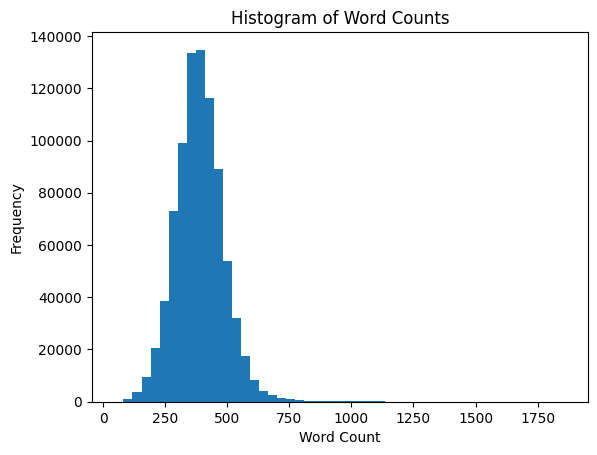

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df2["word_count"], bins=50)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Histogram of Word Counts")
plt.show()

In [20]:
df_filtered = df2[df2["word_count"] > 1200]
df_filtered

,Title,Abstract,Keywords,Label,Journal,Aims,Categories,text,word_count
59796,Radiation Disrupts the Protective Function of ...,Background: Recent advances in multidisciplina...,,337,Clinical Orthopaedics and Related Research,Devoted to disseminating new and important or...,"Sports Science, Medicine (miscellaneous), Orth...",Radiation Disrupts the Protective Function of ...,1535
65069,Interventions for myopia control in children: ...,Background: Myopia is a common refractive erro...,,358,Cochrane Database of Systematic Reviews,The Cochrane Database of Systematic Reviews C...,"Medicine (miscellaneous), Pharmacology (medical)",Interventions for myopia control in children: ...,1218
74153,Convalescent plasma for people with COVID 19: ...,Background: Convalescent plasma may reduce mor...,,358,Cochrane Database of Systematic Reviews,The Cochrane Database of Systematic Reviews C...,"Medicine (miscellaneous), Pharmacology (medical)",Convalescent plasma for people with COVID 19: ...,1323
138881,IL17A F nanobody sonelokimab in patients with ...,Background: Sonelokimab also known as M1095 is...,,1323,The Lancet,The Lancet is an international general medical...,Medicine (miscellaneous),IL17A F nanobody sonelokimab in patients with ...,1348
154901,Systemic corticosteroids for the treatment of ...,Background: Systemic corticosteroids are used ...,,358,Cochrane Database of Systematic Reviews,The Cochrane Database of Systematic Reviews C...,"Medicine (miscellaneous), Pharmacology (medical)",Systemic corticosteroids for the treatment of ...,1260
157021,Alterations in Abundance and Compartmentalizat...,"In this follow up study, we investigated the a...",SIV; THC; c ART; extracellular condensates ECs...,1383,Viruses,Viruses ISSN 1999 4915 is an open access jou...,"Virology, Infectious Diseases",Alterations in Abundance and Compartmentalizat...,1500
160761,What are the Trends in Racial Diversity Among ...,Background: Orthopaedic surgery has recruited ...,,337,Clinical Orthopaedics and Related Research,Devoted to disseminating new and important or...,"Sports Science, Medicine (miscellaneous), Orth...",What are the Trends in Racial Diversity Among ...,1203
160788,Screening for the primary prevention of fragil...,Background: To inform recommendations by the C...,Acceptability; Calibration; Fracture; Guidelin...,1317,Systematic Reviews,Systematic Reviews encompasses all aspects of ...,Medicine (miscellaneous),Screening for the primary prevention of fragil...,1862
176528,Does the Addition of a Vascularized Fibula Imp...,Background: Massive bone allograft with or wit...,,337,Clinical Orthopaedics and Related Research,Devoted to disseminating new and important or...,"Sports Science, Medicine (miscellaneous), Orth...",Does the Addition of a Vascularized Fibula Imp...,1221
196718,Topical anti inflammatory treatments for eczem...,Background: Eczema atopic dermatitis is the mo...,,358,Cochrane Database of Systematic Reviews,The Cochrane Database of Systematic Reviews C...,"Medicine (miscellaneous), Pharmacology (medical)",Topical anti inflammatory treatments for eczem...,1504


In [ ]:
import pandas as pd
journal_full_dataset = pd.read_csv("D:\\File\\train_dataset\\journal_full_info.csv")
journal_full_dataset.info()